# Defense Knowledge Base - Dataset Generator

---

## Purpose

This notebook **runs once** to build a local defense knowledge base by scraping Wikipedia articles and saving them as `.md` files. After this runs successfully:
- All articles are stored in `data/` folder locally
- The main RAG notebook loads from disk - **no internet required during inference**
- No more skipped articles, no rate limits, no wikipedia package issues

## Corpus Structure

```
data/
├── pakistan/          ← PAF, Army, Navy, ISI, ISPR, Operation Swift Retort, Kamra Aeronautical Complex
├── aircraft/          ← JF-17, F-16, Rafale, Typhoon, F-22, J-20
├── missiles/          ← Shaheen, Babur, Nasr, BrahMos, Hypersonic, SAM, Missile Defense
├── tanks/             ← Al-Khalid, M1 Abrams, Leopard 2
├── radar/             ← AESA, AWACS, Phased Array
├── drones/            ← UAV, MQ-9 Reaper
├── technology/        ← Stealth, Electronic Warfare, Cyber Warfare
├── naval/             ← Aircraft Carrier, Submarine
└── concepts/          ← Air Superiority, BVR Missile, Network-Centric Warfare, Aerial Refueling
```

**Run all cells once. Then use the main notebook.**

---

## Step 1 - Install Dependencies

In [1]:
!pip install beautifulsoup4 tqdm requests -q
print('Dependencies installed.')

Dependencies installed.


## Step 2 - Imports

In [2]:
import os
import time
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm

print('Imports successful.')

Imports successful.


## Step 3 - Define the Dataset

Topics are organized into 8 categories. The Pakistan category includes PAF, Army, Navy, ISI, and operation-specific content - making this corpus unique and highly relevant.

In [3]:
DATASET = {
    'pakistan': [
        'Pakistan Army',
        'Pakistan Air Force',
        'Pakistan Navy',
        'Inter-Services Intelligence',
        'Inter-Services Public Relations',
        'Operation Swift Retort',
        'Pakistan Aeronautical Complex', 
    ],
    'aircraft': [
        'JF-17 Thunder',
        'F-16 Fighting Falcon',
        'Dassault Rafale',
        'Eurofighter Typhoon',
        'F-22 Raptor',
        'Chengdu J-20',
    ],
    'missiles': [
        'Shaheen missile',
        'Babur cruise missile',
        'Nasr missile',
        'Surface-to-air missile',
        'Missile defense',
        'BrahMos', 
        'Hypersonic missile', 
    ],
    'tanks': [
        'Al-Khalid tank',
        'M1 Abrams',
        'Leopard 2',
    ],
    'radar': [
        'Active electronically scanned array',
        'Airborne early warning and control',
        'Phased array',
    ],
    'drones': [
        'Unmanned aerial vehicle',
        'MQ-9 Reaper',
        'Counter-UAS',
    ],
    'technology': [
        'Stealth technology',
        'Electronic warfare',
        'Cyber warfare',
    ],
    'naval': [
        'Aircraft carrier',
        'Submarine',
    ],
    'concepts': [   
        'Air superiority',
        'Beyond-visual-range missile',
        'Network-centric warfare',
        'Aerial refueling',
    ],
}

total_topics = sum(len(v) for v in DATASET.values())
print(f'Total topics defined: {total_topics}')
print(f'Categories          : {len(DATASET)}')
for cat, topics in DATASET.items():
    print(f'  {cat:<12} → {len(topics)} topics')

Total topics defined: 38
Categories          : 9
  pakistan     → 7 topics
  aircraft     → 6 topics
  missiles     → 7 topics
  tanks        → 3 topics
  radar        → 3 topics
  drones       → 3 topics
  technology   → 3 topics
  naval        → 2 topics
  concepts     → 4 topics


## Step 4 - Create Folder Structure

In [4]:
for folder in DATASET:
    os.makedirs(f'data/{folder}', exist_ok=True)
    print(f'  Created: data/{folder}/')

print('\nAll folders created.')

  Created: data/pakistan/
  Created: data/aircraft/
  Created: data/missiles/
  Created: data/tanks/
  Created: data/radar/
  Created: data/drones/
  Created: data/technology/
  Created: data/naval/
  Created: data/concepts/

All folders created.


## Step 5 - Wikipedia Scraper

We scrape directly from Wikipedia using `requests` + `BeautifulSoup` - no external package, no rate limit issues, full control over what we extract.

**What we extract per article:**
- All paragraph text from the main content area
- Cleans out reference numbers `[1]`, `[2]` etc.
- Skips empty paragraphs
- Adds YAML-style metadata header for LangChain to parse

In [5]:
HEADERS = {
    'User-Agent': 'Defense-RAG-EducationalProject/1.0'
}

def clean_text(text: str) -> str:
    """Remove reference numbers like [1], [2] from Wikipedia text."""
    import re
    text = re.sub(r'\[\d+\]', '', text)   # remove [1], [23] etc.
    text = re.sub(r'\[note \d+\]', '', text)
    text = re.sub(r' +', ' ', text)        # collapse multiple spaces
    return text.strip()


def scrape_wikipedia(title: str, category: str) -> dict:
    """
    Scrape a Wikipedia article and return structured content.
    Returns a dict with title, category, url, content, char_count.
    Returns None on failure.
    """
    url = 'https://en.wikipedia.org/wiki/' + title.replace(' ', '_')

    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, 'html.parser')

        # Extract main content area
        content_div = soup.find('div', {'id': 'mw-content-text'})
        if content_div is None:
            return None

        # Extract section headings and paragraphs for structure
        body_content = content_div.find('div', {'class': 'mw-parser-output'})
        if body_content is None:
            body_content = content_div

        text_parts = []
        for element in body_content.find_all(['h2', 'h3', 'p']):
            if element.name in ['h2', 'h3']:
                heading = element.get_text().replace('[edit]', '').strip()
                if heading and heading not in ['References', 'External links',
                                               'Notes', 'Bibliography',
                                               'Further reading', 'See also']:
                    text_parts.append(f'\n## {heading}\n')
            elif element.name == 'p':
                para = clean_text(element.get_text())
                if len(para) > 40:  # skip very short/empty paragraphs
                    text_parts.append(para)

        full_text = '\n'.join(text_parts).strip()

        if len(full_text) < 200:
            return None

        return {
            'title':      title,
            'category':   category,
            'url':        url,
            'content':    full_text,
            'char_count': len(full_text)
        }

    except Exception as e:
        print(f'    Error scraping {title}: {e}')
        return None


print('Scraper function defined.')

Scraper function defined.


## Step 6 - Download and Save All Articles

Each article is saved as a `.md` file with a metadata header. A 1-second delay between requests is added to be respectful to Wikipedia's servers.

In [ ]:
success_count = 0
failed_list   = []

print('Downloading articles...\n')

for category, topics in DATASET.items():
    print(f'\n {category.upper()}')

    for topic in tqdm(topics, desc=f'  {category}'):
        # Check if already downloaded — skip if exists
        filename = topic.lower().replace(' ', '_').replace('-', '_')
        filepath = f'data/{category}/{filename}.md'

        if os.path.exists(filepath):
            print(f' Already exists: {topic}')
            success_count += 1
            continue

        # Scrape the article
        result = scrape_wikipedia(topic, category)

        if result is None:
            print(f' Failed: {topic}')
            failed_list.append((category, topic))
            continue

        # Build markdown file content
        md_content = (
            f'---\n'
            f'title: {result["title"]}\n'
            f'category: {result["category"]}\n'
            f'source: {result["url"]}\n'
            f'---\n\n'
            f'# {result["title"]}\n\n'
            f'{result["content"]}'
        )

        # Save to disk
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(md_content)

        success_count += 1
        print(f' Saved: {topic} ({result["char_count"]:,} chars)')

        # Polite delay between requests
        time.sleep(1.0)

print(f'\n{"="*50}')
print(f' Successfully saved : {success_count} articles')
print(f' Failed             : {len(failed_list)}')

if failed_list:
    print('\nFailed articles (retry manually):')
    for cat, topic in failed_list:
        print(f'  [{cat}] {topic}')

## Step 7 - Retry Failed Articles

If any articles failed in Step 6, run this cell to retry them with a longer timeout.

In [7]:
if failed_list:
    print(f'Retrying {len(failed_list)} failed articles...\n')
    still_failed = []

    for category, topic in failed_list:
        time.sleep(2.0)  # longer delay for retry
        result = scrape_wikipedia(topic, category)

        if result is None:
            print(f' Still failed: {topic}')
            still_failed.append((category, topic))
            continue

        filename  = topic.lower().replace(' ', '_').replace('-', '_')
        filepath  = f'data/{category}/{filename}.md'
        md_content = (
            f'---\n'
            f'title: {result["title"]}\n'
            f'category: {result["category"]}\n'
            f'source: {result["url"]}\n'
            f'---\n\n'
            f'# {result["title"]}\n\n'
            f'{result["content"]}'
        )
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(md_content)

        print(f' Recovered: {topic}')

    if still_failed:
        print(f'\n{len(still_failed)} articles still failed.')
        print('These will be skipped — corpus will work fine without them.')
else:
    print('No failed articles to retry. All good!')

Retrying 3 failed articles...

 Still failed: Kamra Aeronautical Complex
 Still failed: BrahMos missile
 Still failed: Counter-unmanned aerial vehicle

3 articles still failed.
These will be skipped — corpus will work fine without them.


In [8]:
# Quick retry for the 3 failed articles only
failed_fixes = [
    ('pakistan', 'Pakistan Aeronautical Complex'),
    ('missiles', 'BrahMos'),
    ('drones',   'Counter-UAS'),
]

for category, topic in failed_fixes:
    result = scrape_wikipedia(topic, category)
    if result is None:
        print(f'Still failed: {topic}')
        continue

    filename = topic.lower().replace(' ', '_').replace('-', '_')
    filepath = f'data/{category}/{filename}.md'
    md_content = (
        f'---\n'
        f'title: {result["title"]}\n'
        f'category: {result["category"]}\n'
        f'source: {result["url"]}\n'
        f'---\n\n'
        f'# {result["title"]}\n\n'
        f'{result["content"]}'
    )
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(md_content)

    print(f'Saved: {topic} ({result["char_count"]:,} chars)')

Saved: Pakistan Aeronautical Complex (9,349 chars)
Saved: BrahMos (39,039 chars)
Still failed: Counter-UAS


In [11]:
failed_fixes = [
    ('drones', 'Counter-drone technology'),
]

for category, topic in failed_fixes:
    result = scrape_wikipedia(topic, category)
    if result is None:
        print(f' Still failed: {topic}')
    else:
        filename = topic.lower().replace(' ', '_').replace('-', '_')
        filepath = f'data/{category}/{filename}.md'
        md_content = (
            f'---\n'
            f'title: {result["title"]}\n'
            f'category: {result["category"]}\n'
            f'source: {result["url"]}\n'
            f'---\n\n'
            f'# {result["title"]}\n\n'
            f'{result["content"]}'
        )
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(md_content)
        print(f' Saved: {topic} ({result["char_count"]:,} chars)')

 Still failed: Counter-drone technology


## Step 8 - Verify the Dataset

In [12]:
import matplotlib.pyplot as plt
import numpy as np

print('Dataset verification:\n')

category_stats = {}
all_files = []

for category in DATASET:
    folder = f'data/{category}'
    files  = [f for f in os.listdir(folder) if f.endswith('.md')]
    sizes  = [os.path.getsize(f'{folder}/{f}') for f in files]
    total  = sum(sizes)

    category_stats[category] = {
        'files': len(files),
        'total_chars': total
    }
    all_files.extend(sizes)

    print(f' {category:<12} : {len(files):2d} files | {total/1000:.1f}K chars')

print(f'\nTotal files  : {sum(v["files"] for v in category_stats.values())}')
print(f'Total corpus : {sum(v["total_chars"] for v in category_stats.values())/1000:.1f}K characters')

Dataset verification:

 pakistan     :  7 files | 289.0K chars
 aircraft     :  6 files | 392.5K chars
 missiles     :  7 files | 121.0K chars
 tanks        :  3 files | 197.7K chars
 radar        :  3 files | 64.2K chars
 drones       :  2 files | 113.9K chars
 technology   :  3 files | 114.1K chars
 naval        :  2 files | 116.5K chars
 concepts     :  4 files | 104.4K chars

Total files  : 37
Total corpus : 1513.4K characters


## Step 9 - Visualize corpus coverage

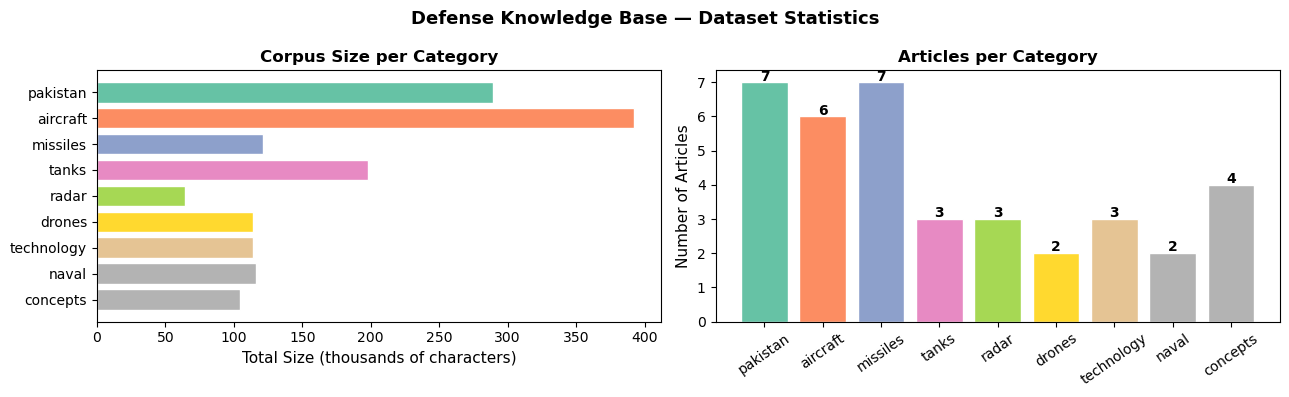

In [13]:
# Visualize corpus coverage
categories = list(category_stats.keys())
total_chars = [v['total_chars'] / 1000 for v in category_stats.values()]
file_counts = [v['files'] for v in category_stats.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

axes[0].barh(categories, total_chars, color=colors, edgecolor='white')
axes[0].set_xlabel('Total Size (thousands of characters)', fontsize=11)
axes[0].set_title('Corpus Size per Category', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

axes[1].bar(categories, file_counts, color=colors, edgecolor='white')
axes[1].set_ylabel('Number of Articles', fontsize=11)
axes[1].set_title('Articles per Category', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
for i, v in enumerate(file_counts):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Defense Knowledge Base — Dataset Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.1 Preview one file to confirm quality

In [14]:
# Preview one file to confirm quality
sample_path = 'data/aircraft/jf_17_thunder.md'
if os.path.exists(sample_path):
    with open(sample_path, 'r', encoding='utf-8') as f:
        content = f.read()
    print(f'Sample file: {sample_path}')
    print(f'Total length: {len(content):,} characters')
    print('\nFirst 800 characters:')
    print('-' * 60)
    print(content[:800])
else:
    print('JF-17 file not found — check if download succeeded.')

Sample file: data/aircraft/jf_17_thunder.md
Total length: 51,569 characters

First 800 characters:
------------------------------------------------------------
---
title: JF-17 Thunder
category: aircraft
source: https://en.wikipedia.org/wiki/JF-17_Thunder
---

# JF-17 Thunder

The CAC/PAC JF-17 Thunder,[a] also known as FC-1 Xiaolong,[b] is a Sino-Pakistani single-engine lightweight supersonic multirole combat aircraft developed jointly by the Pakistan Aeronautical Complex (PAC) and the Chengdu Aircraft Corporation (CAC) of China. It is a fourth-generation fighter, designed and developed as a replacement for the third-generation A-5C, F-7P/PG, Mirage III, and Mirage 5 combat aircraft in the Pakistan Air Force (PAF). The JF-17 can be used for multiple roles, including interception, ground attack, anti-ship, and aerial reconnaissance. The Pakistani designation "JF-17" stands for "Joint Fighter-17", with the "Joint Fighter" denoting the joint Pakist


---
##  Dataset Ready

The local defense knowledge base is built. Now we have:

- All articles saved as structured `.md` files in `data/`
- YAML metadata headers (title, category, source URL) on every file
- Clean text with reference numbers removed and sections preserved

**Next step:** Open `task4_defense_rag_lcel.ipynb` and run it. The main notebook loads from `data/` using `DirectoryLoader` - no internet needed.

**We never need to run this generator again** unless we want to add new topics.